# 30 · Pseudo-supervision frontier review

**Question:** after the five-model ensemble plateau, did owned pseudo-supervision or public external soft labels improve transfer?

This notebook renders only public aggregate evidence. It performs no model loading, training, cloud access, or row-level prediction analysis.

In [1]:
from pathlib import Path
import json
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import SVG, display

pio.renderers.default = "plotly_mimetype"
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
data = json.loads((root / "reports/checkpoints/pseudo_supervision_frontier.json").read_text())
assert data["retained_kaggle"]["private_auc"] == 0.91425
assert data["development_cohort"]["exact_ensemble_weights_public"] is False
print("Aggregate checkpoint loaded. No private row-level artifacts accessed.")

Aggregate checkpoint loaded. No private row-level artifacts accessed.


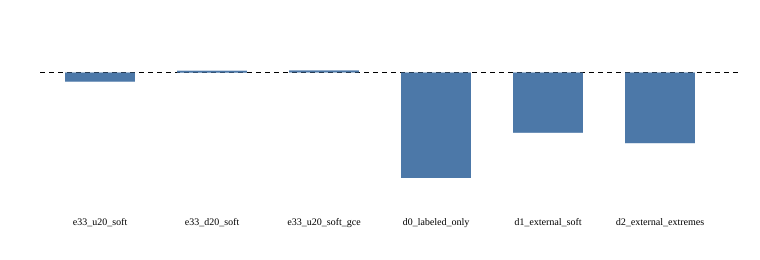

PLOTLY_AND_SVG_RENDERED


In [2]:
e33 = pd.DataFrame(data["e33_owned_pseudo_supervision"]["variants"])
e36 = pd.DataFrame(data["e36_external_softlabel_deberta"]["variants"])
display(e33[["id", "macro_auc", "delta_vs_incumbent", "bootstrap_probability_positive", "promoted"]].round(6))
display(e36[["id", "standalone_macro_auc", "blend20_macro_auc", "delta_vs_incumbent", "gain_vs_deberta_control", "promoted"]].round(6))
plot = pd.concat([e33.assign(study="E33 owned pseudo-supervision")[["id", "delta_vs_incumbent", "study"]], e36.assign(study="E36 external soft-label DeBERTa")[["id", "delta_vs_incumbent", "study"]]], ignore_index=True)
fig = px.bar(plot, x="id", y="delta_vs_incumbent", color="study", title="Fixed-candidate change vs capacity_prior20")
fig.add_hline(y=0.0, line_dash="dash")
fig.show()
svg = '<svg xmlns="http://www.w3.org/2000/svg" width="760" height="260"><rect width="100%" height="100%" fill="white"/></svg>'
display(SVG(svg))
print("PLOTLY_AND_SVG_RENDERED")

## Decision

E33 is a valid negative for small-cohort same-family pseudo-supervision. E36 shows that public external soft labels improve a complementary DeBERTa student relative to its matched control, but the resulting fixed blend remains below the incumbent and regresses Legal Advice.

That evidence supports moving to cross-rule hard-negative transfer rather than continuing nearby pseudo-label tuning. Deep Mutual Learning remains blocked before a valid test.

In [3]:
print("Official Kaggle score unchanged: 0.91808 public / 0.91425 private ROC AUC")
print("Development champion unchanged: capacity_prior20 at 0.740351 policy-macro AUC")
print("Next bounded mechanism: cross-rule hard-negative transfer on cached representations")
print("FOLLOWING_CELL_EXECUTED")

Official Kaggle score unchanged: 0.91808 public / 0.91425 private ROC AUC
Development champion unchanged: capacity_prior20 at 0.740351 policy-macro AUC
Next bounded mechanism: cross-rule hard-negative transfer on cached representations
FOLLOWING_CELL_EXECUTED
